# Ensemble: GNN + fingerprint tree — **different feature layouts**

This notebook trains **`EnsembleRegressor`(`GNNRegressor`, `FingerprintEnsembleMember`)** where:

1. **Tree (HGB)** — molecule-level **tabular** features: row-wise **concatenation** of **`rdkit_phys_props`** and **`morgan_r1_count_512`** (same order as `baseline` / `build_descriptor_matrix`).
2. **GNN** — **PyG graphs** with **extra node channels**: the **same two** descriptors are passed as `descriptor_name=("rdkit_phys_props", "morgan_r1_count_512")` on `GraphRegressionDataset`, so each molecule’s phys + Morgan vector is **broadcast onto atoms** (see `models.data.graph`). That is a different inductive bias than a single flat fingerprint row for HGB.

Aligned **`X_fp`** is required for `fit` / `predict` on the fingerprint member. The graph member ignores `X_fp`.

**Requires:** `pip install openadnet[dl]`. `load_data` may download the training CSV once.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from rdkit import Chem
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

_REPO = Path.cwd().resolve()
if not (_REPO / "src" / "baseline.py").exists():
    _REPO = _REPO.parent
sys.path.insert(0, str(_REPO / "src"))

from baseline import BaselineCVConfig, default_regressors, prepare_training_data
from features_data import build_descriptor_matrix, descriptor_dim_total
from load_data import train
from models import EnsembleRegressor, FingerprintEnsembleMember, GNNRegressor
from models.data import GraphRegressionDataset

plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 0
Y_COL = "pEC50"
# Tree: concat these columns; GNN: broadcast these onto graph nodes (same names, different layout)
DESCRIPTORS: tuple[str, ...] = ( "morgan_r1_count_512", "rdkit_phys_props")
N_MAX = 3300
TEST_SIZE = 0.2
GNN_EPOCHS = 50
WEIGHTS = [0.5, 0.5]

## Build tabular `X_fp` (tree) vs graph datasets (GNN)

`concat_tabular_descriptors` stacks **`rdkit_phys_props`** then **`morgan_r1_count_512`** horizontally. Width = `descriptor_dim_total(DESCRIPTORS)`.

In [2]:
def concat_tabular_descriptors(names: tuple[str, ...], mols: list) -> np.ndarray:
    parts = [build_descriptor_matrix(n, mols).astype(np.float64) for n in names]
    return np.hstack(parts)


mols = list(train["SMILES"].apply(Chem.MolFromSmiles))
y_all, mols_f, mask = prepare_training_data(train, mols, y_col=Y_COL)
train_f = train.loc[mask].reset_index(drop=True)
X_fp = concat_tabular_descriptors(DESCRIPTORS, mols_f)
smiles_all = train_f["SMILES"].astype(str).tolist()

rng = np.random.RandomState(RANDOM_STATE)
n = len(y_all)
take = rng.choice(n, size=min(N_MAX, n), replace=False)
y = y_all[take]
X_fp = X_fp[take]
smiles_all = [smiles_all[i] for i in take]

print(
    f"n={len(y)} | tree X_fp {X_fp.shape} "
    f"(dim {descriptor_dim_total(DESCRIPTORS)} = phys + morgan_512)"
)
print("GNN will use descriptor_name", DESCRIPTORS)

n=3300 | tree X_fp (3300, 527) (dim 527 = phys + morgan_512)
GNN will use descriptor_name ('morgan_r1_count_512', 'rdkit_phys_props')


## Train / test split

Graph datasets use `descriptor_name=DESCRIPTORS` so the GNN’s `in_dim` matches `GNNRegressor(..., descriptor_name=DESCRIPTORS)`.

In [3]:
ix = np.arange(len(y))
ix_train, ix_test = train_test_split(
    ix, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
y_train, y_test = y[ix_train], y[ix_test]
X_tr, X_te = X_fp[ix_train], X_fp[ix_test]
smi_tr = [smiles_all[i] for i in ix_train]
smi_te = [smiles_all[i] for i in ix_test]

ds_train = GraphRegressionDataset(
    smi_tr, y_train.reshape(-1, 1), descriptor_name=DESCRIPTORS
)
ds_test = GraphRegressionDataset(
    smi_te, y_test.reshape(-1, 1), descriptor_name=DESCRIPTORS
)
print("train", len(ds_train), "test", len(ds_test))

train 2640 test 660


## Ensemble: GNN (graph + broadcast descriptors) + HGB (flat concat)

`GNNRegressor(..., descriptor_name=DESCRIPTORS)` must match the dataset.

In [4]:
cfg = BaselineCVConfig(y_col=Y_COL, model_random_state=RANDOM_STATE)
regs = default_regressors(cfg.model_random_state)

fp_member = FingerprintEnsembleMember("hgb", regs["hgb"], n_tasks=1)
gnn = GNNRegressor(
    n_tasks=1,
    descriptor_name=DESCRIPTORS,
    hidden_dim=64,
    num_layers=3,
    architecture="mpnn", 
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

ens = EnsembleRegressor([gnn, fp_member], weights=WEIGHTS)
hist = ens.fit(
    ds_train,
    X_fp=X_tr,
    epochs=GNN_EPOCHS,
    batch_size=32,
    show_progress=False,
)
print("GNN epoch losses (last 3):", hist[0][-3:] if hist[0] else None)

GNN epoch losses (last 3): [0.18165976967079095, 0.17982092598475605, 0.17627684570041047]


## Test metrics

Pass **`X_fp=X_te`** for the tree member.

In [5]:
def row(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    return {
        "model": name,
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


pred_gnn = gnn.predict(ds_test, show_progress=False).ravel()
pred_fp = fp_member.predict(ds_test, X_fp=X_te).ravel()
pred_ens = ens.predict(ds_test, X_fp=X_te, show_progress=False).ravel()

rows = [
    row("GNN (graph + node descriptors)", y_test, pred_gnn),
    row("HGB (concat phys + morgan_512)", y_test, pred_fp),
    row("Ensemble (0.5 GNN + 0.5 HGB)", y_test, pred_ens),
]
metrics = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
display(metrics)

,model,rmse,mae,r2
0,Ensemble (0.5 GNN + 0.5 HGB),0.748888,0.546995,0.553380
1,HGB (concat phys + morgan_512),0.749409,0.558266,0.552758
2,GNN (graph + node descriptors),0.854780,0.630818,0.418147


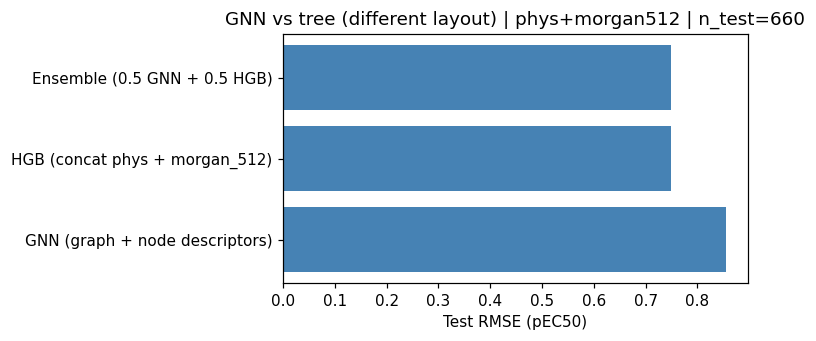

In [6]:
feat_label = "phys+morgan512"
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(metrics["model"], metrics["rmse"], color="steelblue")
ax.set_xlabel("Test RMSE (pEC50)")
ax.invert_yaxis()
ax.set_title(f"GNN vs tree (different layout) | {feat_label} | n_test={len(y_test)}")
plt.tight_layout()
plt.show()

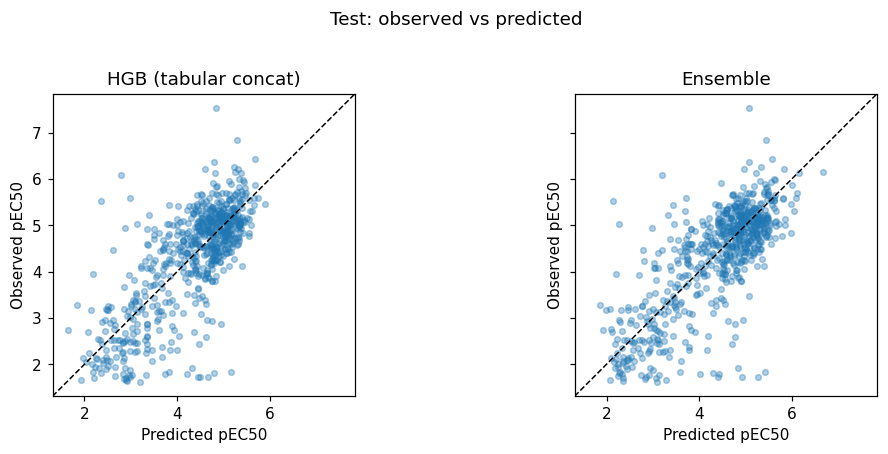

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
y_obs = y_test.ravel()
lims = (float(y_obs.min()) - 0.3, float(y_obs.max()) + 0.3)
for ax, (title, yp) in zip(
    axes,
    [
        ("HGB (tabular concat)", pred_fp),
        ("Ensemble", pred_ens),
    ],
):
    ax.scatter(yp, y_obs, alpha=0.35, s=14)
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Predicted pEC50")
    ax.set_ylabel("Observed pEC50")
    ax.set_title(title)
plt.suptitle("Test: observed vs predicted", y=1.02)
plt.tight_layout()
plt.show()

### Notes

- **Same chemical information, two views:** tabular concat for the tree vs **node-broadcast** descriptors on the GNN (see [`graph.py`](../src/models/data/graph.py) `GraphRegressionDataset`).
- To use **only** atom/bond features on the GNN, set `descriptor_name=None` on the datasets and omit `descriptor_name` on `GNNRegressor`; keep **`DESCRIPTORS`** for **`X_fp`** only — then the two heads use **different** descriptor sets.
- Tune **`WEIGHTS`**, **`N_MAX`**, **`GNN_EPOCHS`**; use nested CV for unbiased scores.